# heart D . Decision Tree

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


In [70]:
data = pd.read_csv('HeartDisease.csv')

In [71]:
data.isnull().sum()

age                    0
gender                 0
chest_pain             0
rest_bps               0
cholestrol             0
fasting_blood_sugar    0
rest_ecg               0
thalach                0
exer_angina            0
old_peak               0
slope                  0
ca                     0
thalassemia            0
target                 0
dtype: int64

In [72]:
data.describe()

,age,gender,chest_pain,rest_bps,cholestrol,fasting_blood_sugar,rest_ecg,thalach,exer_angina,old_peak,slope,ca,thalassemia,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  303 non-null    int64  
 1   gender               303 non-null    int64  
 2   chest_pain           303 non-null    int64  
 3   rest_bps             303 non-null    int64  
 4   cholestrol           303 non-null    int64  
 5   fasting_blood_sugar  303 non-null    int64  
 6   rest_ecg             303 non-null    int64  
 7   thalach              303 non-null    int64  
 8   exer_angina          303 non-null    int64  
 9   old_peak             303 non-null    float64
 10  slope                303 non-null    int64  
 11  ca                   303 non-null    int64  
 12  thalassemia          303 non-null    int64  
 13  target               303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [11]:
data.value_counts().isnull().sum()

0

In [13]:
#____________1.target
data.target.value_counts()

1    165
0    138
Name: target, dtype: int64

Text(0.5, 1.0, 'BARPLOT OF target')

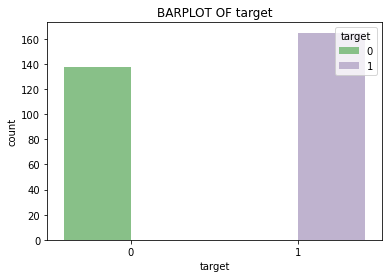

In [98]:

sns.countplot(x=data.target,hue=data.target,palette='Accent')
plt.title('BARPLOT OF target')

In [16]:
##_________________2. thalassemia [ordered-0,1,2,3]
data.thalassemia.value_counts()

2    166
3    117
1     18
0      2
Name: thalassemia, dtype: int64

Text(0.5, 1.0, 'BARPLOT OF thalassemia')

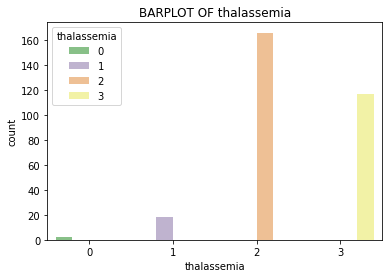

In [99]:
sns.countplot(x=data.thalassemia,hue=data.thalassemia,palette='Accent')
plt.title('BARPLOT OF thalassemia')

<AxesSubplot:>

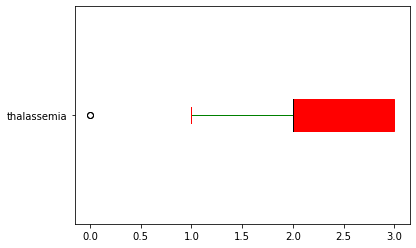

In [78]:
#boxplot
props2 = dict(boxes ='red', whiskers ='green', medians ='black', caps='red')
data['thalassemia'].plot.box(color=props2, patch_artist =True,  vert =False)



In [20]:
##_________________3. ca[ordered-0,1,2,3,4 ]
data.ca.value_counts()

0    175
1     65
2     38
3     20
4      5
Name: ca, dtype: int64

Text(0.5, 1.0, 'BARPLOT OF CA')

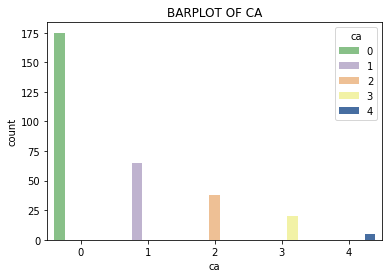

In [100]:
sns.countplot(x=data.ca,hue=data.ca,palette='Accent')
plt.title('BARPLOT OF CA')

<AxesSubplot:>

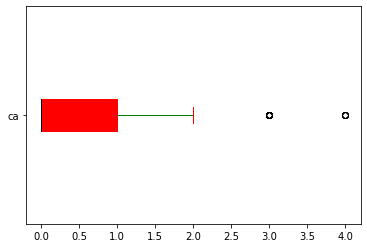

In [79]:
#boxplot
props2 = dict(boxes ='red', whiskers ='green', medians ='black', caps='red')
data['ca'].plot.box(color=props2, patch_artist =True,  vert =False)


In [25]:
##_________________4. slope[ordered-0,1,2]
data.slope.value_counts()

2    142
1    140
0     21
Name: slope, dtype: int64

Text(0.5, 1.0, 'BARPLOT OF SLOPE')

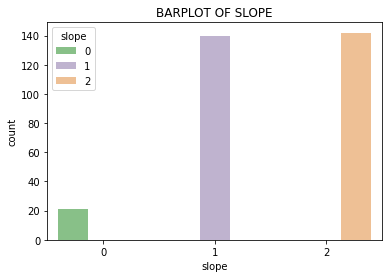

In [101]:
sns.countplot(x=data.slope,hue=data.slope,palette='Accent')
plt.title('BARPLOT OF SLOPE')

<AxesSubplot:>

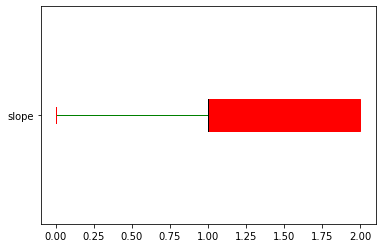

In [80]:
#boxplot
props2 = dict(boxes ='red', whiskers ='green', medians ='black', caps='red')
data['slope'].plot.box(color=props2, patch_artist =True,  vert =False)


In [29]:
##_________________5. OLD_PEAK
data.old_peak.value_counts()

0.0    99
1.2    17
1.0    14
0.6    14
1.4    13
0.8    13
0.2    12
1.6    11
1.8    10
0.4     9
2.0     9
0.1     7
2.8     6
2.6     6
1.5     5
3.0     5
1.9     5
0.5     5
3.6     4
2.2     4
2.4     3
0.9     3
3.4     3
4.0     3
0.3     3
2.3     2
3.2     2
2.5     2
4.2     2
1.1     2
3.1     1
0.7     1
3.5     1
6.2     1
1.3     1
5.6     1
2.9     1
2.1     1
3.8     1
4.4     1
Name: old_peak, dtype: int64

Text(0.5, 1.0, 'HISTOGRAM OF H1N1 OLD_PEAK')

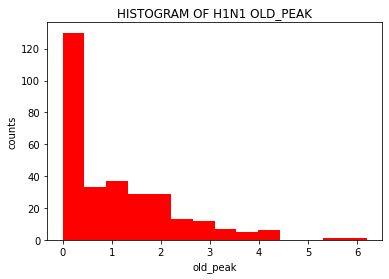

In [97]:
plt.hist(data.old_peak,bins='auto',facecolor='red')
plt.xlabel('old_peak')
plt.ylabel('counts')
plt.title('HISTOGRAM OF H1N1 OLD_PEAK')

<AxesSubplot:>

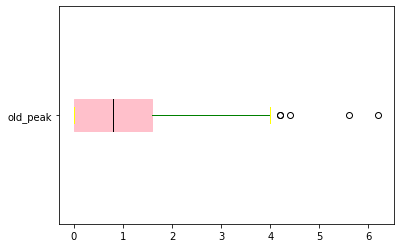

In [108]:
#boxplot
props2 = dict(boxes ='pink', whiskers ='green', medians ='black', caps='yellow')
data['old_peak'].plot.box(color=props2, patch_artist =True,  vert =False)


In [34]:
##_________________6. exer_angina
data.exer_angina.value_counts()

0    204
1     99
Name: exer_angina, dtype: int64

Text(0.5, 1.0, 'BARPLOT OF exer_angina')

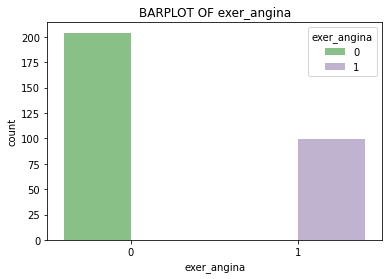

In [102]:
sns.countplot(x=data.exer_angina,hue=data.exer_angina,palette='Accent')
plt.title('BARPLOT OF exer_angina')

In [41]:
##_________________7. thalach
data.thalach.value_counts()

162    11
160     9
163     9
152     8
173     8
       ..
202     1
184     1
121     1
192     1
90      1
Name: thalach, Length: 91, dtype: int64

<AxesSubplot:>

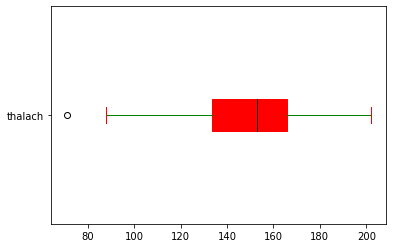

In [84]:
#boxplot
props2 = dict(boxes ='red', whiskers ='green', medians ='black', caps='red')
data['thalach'].plot.box(color=props2, patch_artist =True,  vert =False)


Text(0.5, 1.0, 'HISTOGRAM OF H1N1 thalach')

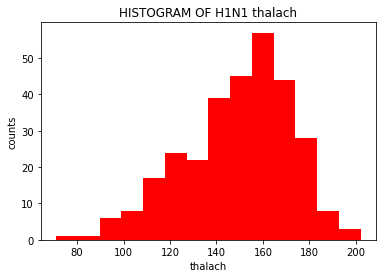

In [43]:
plt.hist(data.thalach,bins='auto',facecolor='red')
plt.xlabel('thalach')
plt.ylabel('counts')
plt.title('HISTOGRAM OF H1N1 thalach')

In [45]:
##_________________8. rest_ecg
data.rest_ecg.value_counts()

1    152
0    147
2      4
Name: rest_ecg, dtype: int64

Text(0.5, 1.0, 'BARPLOT OF rest_ecg')

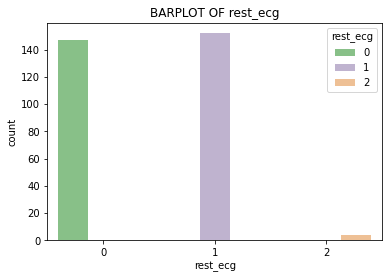

In [103]:
sns.countplot(x=data.rest_ecg,hue=data.rest_ecg,palette='Accent')
plt.title('BARPLOT OF rest_ecg')

<AxesSubplot:>

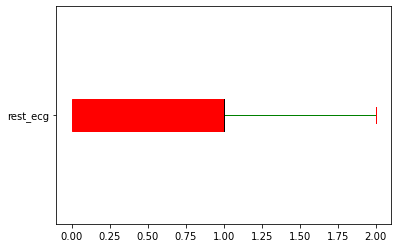

In [85]:
#boxplot
props2 = dict(boxes ='red', whiskers ='green', medians ='black', caps='red')
data['rest_ecg'].plot.box(color=props2, patch_artist =True,  vert =False)


In [48]:
##_________________9. fasting_blood_sugar
data.fasting_blood_sugar.value_counts()

0    258
1     45
Name: fasting_blood_sugar, dtype: int64

Text(0.5, 1.0, 'BARPLOT OF fasting_blood_sugar')

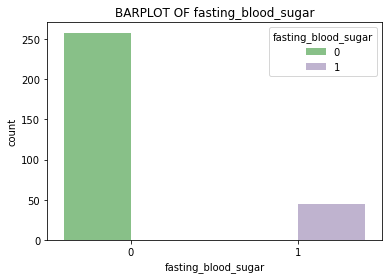

In [104]:
sns.countplot(x=data.fasting_blood_sugar,hue=data.fasting_blood_sugar,palette='Accent')
plt.title('BARPLOT OF fasting_blood_sugar')

In [51]:
##_________________10. cholestrol           
data.cholestrol.value_counts()

204    6
197    6
234    6
269    5
254    5
      ..
284    1
224    1
167    1
276    1
131    1
Name: cholestrol, Length: 152, dtype: int64

<AxesSubplot:>

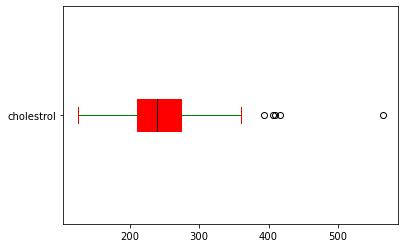

In [89]:
#boxplot
props2 = dict(boxes ='red', whiskers ='green', medians ='black', caps='red')
data['cholestrol'].plot.box(color=props2, patch_artist =True,  vert =False)


Text(0.5, 1.0, 'HISTOGRAM OF H1N1 cholestrol')

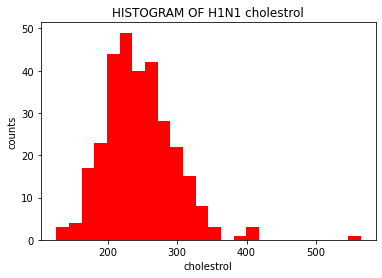

In [53]:
plt.hist(data.cholestrol,bins='auto',facecolor='red')
plt.xlabel('cholestrol')
plt.ylabel('counts')
plt.title('HISTOGRAM OF H1N1 cholestrol')

In [54]:
##_________________11. rest_bps           
data.rest_bps.value_counts()

120    37
130    36
140    32
110    19
150    17
138    13
128    12
160    11
125    11
112     9
132     8
118     7
124     6
135     6
108     6
152     5
134     5
145     5
122     4
170     4
100     4
105     3
126     3
115     3
180     3
136     3
142     3
102     2
148     2
178     2
94      2
144     2
146     2
200     1
114     1
154     1
123     1
192     1
174     1
165     1
104     1
117     1
101     1
156     1
106     1
155     1
129     1
172     1
164     1
Name: rest_bps, dtype: int64

Text(0.5, 1.0, 'HISTOGRAM OF H1N1 rest_bps')

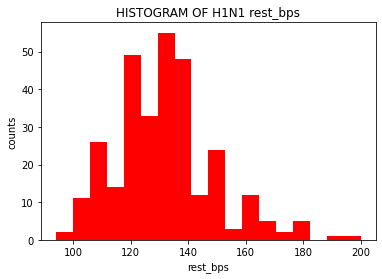

In [55]:
plt.hist(data.rest_bps,bins='auto',facecolor='red')
plt.xlabel('rest_bps')
plt.ylabel('counts')
plt.title('HISTOGRAM OF H1N1 rest_bps')

<AxesSubplot:>

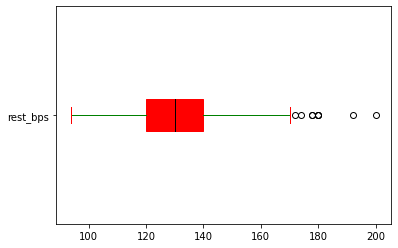

In [90]:
#boxplot
props2 = dict(boxes ='red', whiskers ='green', medians ='black', caps='red')
data['rest_bps'].plot.box(color=props2, patch_artist =True,  vert =False)


In [58]:
##_________________12. rest_bps           
data.chest_pain.value_counts()

0    143
2     87
1     50
3     23
Name: chest_pain, dtype: int64

Text(0.5, 1.0, 'BARPLOT OF chest_pain')

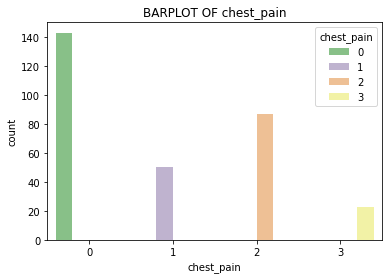

In [105]:
sns.countplot(x=data.chest_pain,hue=data.chest_pain,palette='Accent')
plt.title('BARPLOT OF chest_pain')

<AxesSubplot:>

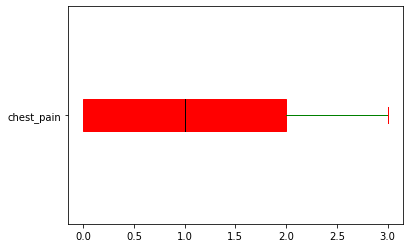

In [91]:
#boxplot
props2 = dict(boxes ='red', whiskers ='green', medians ='black', caps='red')
data['chest_pain'].plot.box(color=props2, patch_artist =True,  vert =False)


In [62]:
##_________________13. gender           
data.gender.value_counts()

1    207
0     96
Name: gender, dtype: int64

Text(0.5, 1.0, 'BARPLOT OF gender')

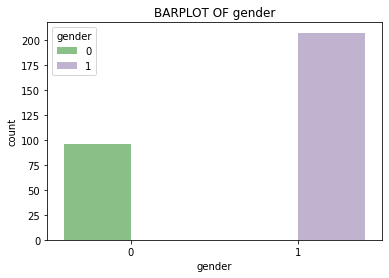

In [106]:
sns.countplot(x=data.gender,hue=data.gender,palette='Accent')
plt.title('BARPLOT OF gender')

In [65]:
##_________________14.age           
data.age.value_counts()

58    19
57    17
54    16
59    14
52    13
51    12
62    11
60    11
44    11
56    11
64    10
41    10
63     9
67     9
65     8
43     8
45     8
55     8
42     8
61     8
53     8
46     7
48     7
66     7
50     7
49     5
47     5
70     4
39     4
35     4
68     4
38     3
71     3
40     3
69     3
34     2
37     2
29     1
74     1
76     1
77     1
Name: age, dtype: int64

Text(0.5, 1.0, 'HISTOGRAM OF H1N1 age')

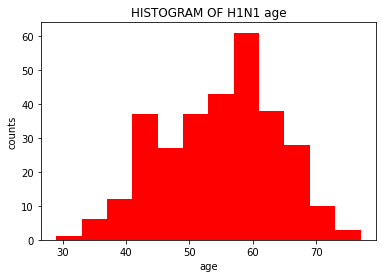

In [66]:
plt.hist(data.age,bins='auto',facecolor='red')
plt.xlabel('age')
plt.ylabel('counts')
plt.title('HISTOGRAM OF H1N1 age')

<AxesSubplot:>

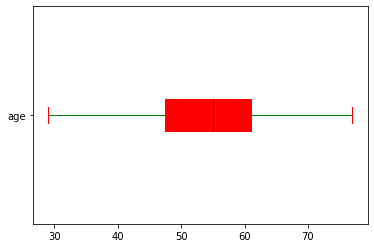

In [93]:
#boxplot
props2 = dict(boxes ='red', whiskers ='green', medians ='black', caps='red')
data['age'].plot.box(color=props2, patch_artist =True,  vert =False)


# PRE PROCESSING DATA

In [112]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import roc_curve,auc,roc_auc_score


In [113]:
x=data.iloc[:,data.columns != 'target']
y=data.iloc[:,data.columns =='target']

In [116]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=123)

In [119]:
y_train.target.value_counts()

1    119
0     93
Name: target, dtype: int64

In [120]:
y_test.target.value_counts()

1    46
0    45
Name: target, dtype: int64

In [123]:
### model
dat = tree.DecisionTreeClassifier()
datmodel =dat.fit(x_train,y_train)

[Text(0.4695121951219512, 0.95, 'X[2] <= 0.5\ngini = 0.492\nsamples = 212\nvalue = [93, 119]'),
 Text(0.21951219512195122, 0.85, 'X[11] <= 0.5\ngini = 0.407\nsamples = 95\nvalue = [68, 27]'),
 Text(0.0975609756097561, 0.75, 'X[12] <= 2.5\ngini = 0.496\nsamples = 44\nvalue = [20, 24]'),
 Text(0.04878048780487805, 0.65, 'X[10] <= 0.5\ngini = 0.26\nsamples = 26\nvalue = [4, 22]'),
 Text(0.024390243902439025, 0.55, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.07317073170731707, 0.55, 'X[7] <= 96.5\ngini = 0.211\nsamples = 25\nvalue = [3, 22]'),
 Text(0.04878048780487805, 0.45, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.0975609756097561, 0.45, 'X[0] <= 60.0\ngini = 0.153\nsamples = 24\nvalue = [2, 22]'),
 Text(0.07317073170731707, 0.35, 'gini = 0.0\nsamples = 17\nvalue = [0, 17]'),
 Text(0.12195121951219512, 0.35, 'X[7] <= 166.0\ngini = 0.408\nsamples = 7\nvalue = [2, 5]'),
 Text(0.0975609756097561, 0.25, 'X[8] <= 0.5\ngini = 0.278\nsamples = 6\nvalue = [1, 5]'),
 Text(0.073

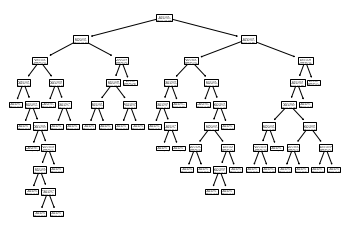

In [124]:
###tree plot
tree.plot_tree(datmodel)

In [125]:
y_predict = datmodel.predict(x_test) 

In [126]:
###classification matrix
confusion_matrix(y_test,y_predict)

array([[33, 12],
       [ 9, 37]], dtype=int64)

In [127]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.79      0.73      0.76        45
           1       0.76      0.80      0.78        46

    accuracy                           0.77        91
   macro avg       0.77      0.77      0.77        91
weighted avg       0.77      0.77      0.77        91



In [131]:
### ROC curve
from sklearn.metrics import roc_curve,auc,roc_auc_score
y_pred_prob = datmodel.predict_proba(x_test)
fpr,tpr,thresholds =roc_curve(y_test,y_pred_prob[:,1])
roc_auc = auc(fpr,tpr)
print (roc_auc)


0.768840579710145


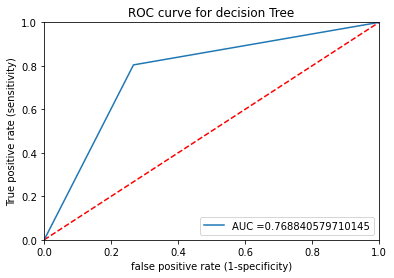

In [132]:
#ROC Curve
plt.title('ROC curve for decision Tree')
plt.xlabel('false positive rate (1-specificity)')
plt.ylabel('True positive rate (sensitivity)')
plt.plot([0,1],[0,1],'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.plot(fpr,tpr,label = 'AUC ='+str(roc_auc))
plt.legend(loc=4)